In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv("../data/features.csv")
df.head()

Data loaded successfully: 100 games found.


,minutes_slept,minutes_awake,env_score,light,target
0,-0.254296,-0.389248,0.036032,1.362831,0.5
1,1.363265,-0.384498,0.081841,-0.780427,1.0
2,-0.160251,-1.595850,-0.672150,0.163783,0.5
3,0.018433,1.349399,0.538693,-1.146349,1.0
4,-0.480002,-0.769280,0.452027,1.578464,1.0


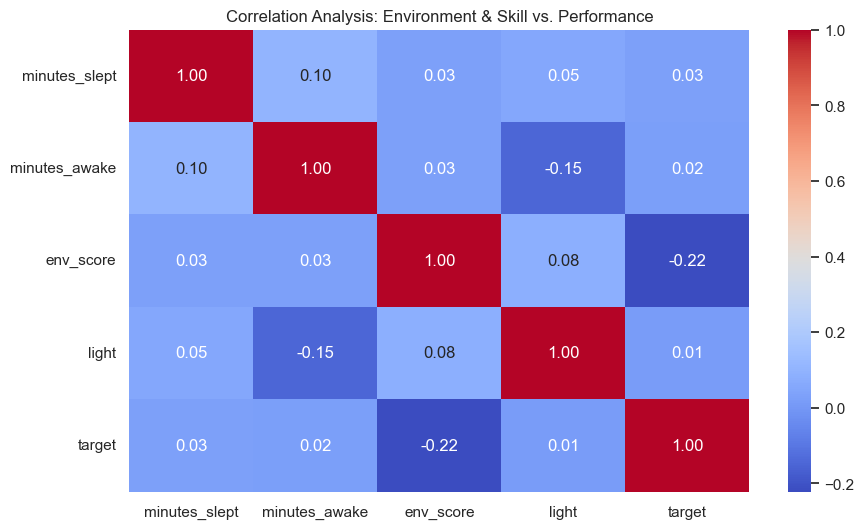

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Analysis: Environment & Skill vs. Performance")
plt.show()

In [20]:

X = df.drop('target', axis='columns')
y = df['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
#prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

In [ ]:
#1 predic win 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_val_scaled)
lr_mse = mean_squared_error(y_val, lr_preds)

#2 finds secrets patterns between sensors
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_val_scaled)
rf_mse = mean_squared_error(y_val, rf_preds)

#3 predicting the probabiolity of whinning 
y_train_class = (y_train * 2).astype(int) 
y_val_class = (y_val * 2).astype(int)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train_class)


log_acc = log_reg.score(X_val_scaled, y_val_class)

print(f"Results Comparison:")
print(f"Linear Regression MSE: {lr_mse:.4f}")
print(f"Random Forest MSE:     {rf_mse:.4f}")
print(f"Logistic Reg. Accuracy: {log_acc:.2%}")

Results Comparison:
Linear Regression MSE: 0.0650
Random Forest MSE:     0.0646
Logistic Reg. Accuracy: 50.00%


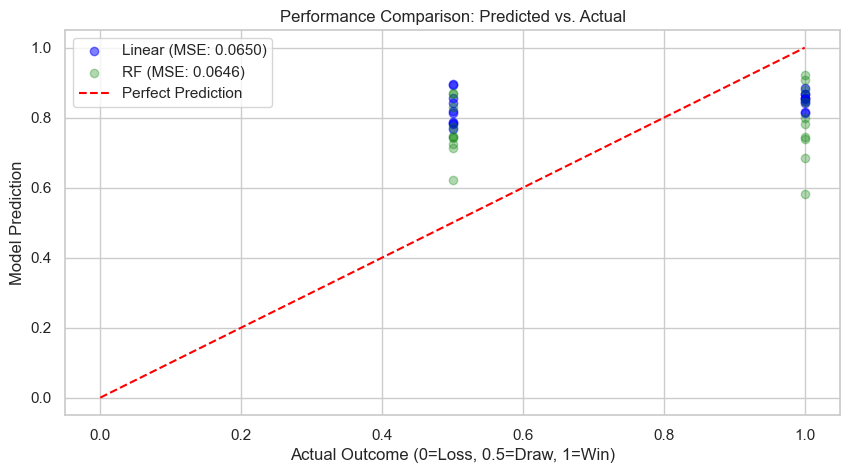

In [ ]:
plt.figure(figsize=(10, 5))


plt.scatter(y_val, lr_preds, alpha=0.5, label=f'Linear (MSE: {lr_mse:.4f})', color='blue')
plt.scatter(y_val, rf_preds, alpha=0.3, label=f'RF (MSE: {rf_mse:.4f})', color='green')

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel("Actual Outcome (0=Loss, 0.5=Draw, 1=Win)")
plt.ylabel("Model Prediction")
plt.title("Performance Comparison: Predicted vs. Actual")
plt.legend()
plt.show()